# Chapitre 6 — Structuration et transformation

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Restructurer** des DataFrames avec pivot et melt selon les besoins d'analyse
2. **Combiner** des sources de données avec merge et concat en choisissant la bonne méthode
3. **Agréger** des données avec groupby et créer des statistiques par groupe
4. **Créer** de nouvelles variables pertinentes (feature engineering) pour l'analyse et le ML

## 6.1 Restructuration des DataFrames (Pratique)

### Pivot : Long → Wide

In [7]:
import pandas as pd
import numpy as np

# Données en format long
df_long = pd.DataFrame({
    'client': ['Alice', 'Alice', 'Alice', 'Bob', 'Bob', 'Bob'],
    'mois': ['Jan', 'Fev', 'Mar', 'Jan', 'Fev', 'Mar'],
    'ventes': [100, 150, 120, 200, 180, 220]
})
# on doit avoir une ligne par client et par mois sinon on ne peut pas pivoter correctement
# sinon aggrégation nécessaire avant pivot

print("Format LONG :")
print(df_long)

Format LONG :
  client mois  ventes
0  Alice  Jan     100
1  Alice  Fev     150
2  Alice  Mar     120
3    Bob  Jan     200
4    Bob  Fev     180
5    Bob  Mar     220


In [8]:
# Pivot vers format wide
df_wide = df_long.pivot(
    index='client',     # Devient les lignes
    columns='mois',     # Devient les colonnes
    values='ventes'     # Les valeurs à répartir
)

print("Format WIDE après pivot :")
print(df_wide)

Format WIDE après pivot :
mois    Fev  Jan  Mar
client               
Alice   150  100  120
Bob     180  200  220


### Pivot Table : avec agrégation

In [3]:
# Quand il y a plusieurs valeurs par combinaison
df = pd.DataFrame({
    'client': ['Alice', 'Alice', 'Alice', 'Bob', 'Bob'],
    'categorie': ['A', 'A', 'B', 'A', 'B'],
    'montant': [100, 150, 200, 300, 250]
})

print("Données avec plusieurs valeurs par combinaison :")
print(df)

Données avec plusieurs valeurs par combinaison :
  client categorie  montant
0  Alice         A      100
1  Alice         A      150
2  Alice         B      200
3    Bob         A      300
4    Bob         B      250


In [4]:
# Pivot avec somme des montants
df_pivot = pd.pivot_table(
    df,
    index='client',
    columns='categorie',
    values='montant',
    aggfunc='sum',           # Fonction d'agrégation
    fill_value=0             # Remplacer NaN par 0
)

print("\nPivot table avec agrégation :")
print(df_pivot)


Pivot table avec agrégation :
categorie    A    B
client             
Alice      250  200
Bob        300  250


### ✍️ Exercice 6.1 : Pivot de ventes (10 min)

In [9]:
import pandas as pd

# Ventes par région et trimestre
df = pd.DataFrame({
    'region': ['Nord', 'Nord', 'Nord', 'Nord', 'Sud', 'Sud', 'Sud', 'Sud'],
    'trimestre': ['Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4'],
    'ventes': [1000, 1200, 1100, 1500, 800, 900, 850, 1000]
})

print("Données originales :")
print(df)

Données originales :
  region trimestre  ventes
0   Nord        Q1    1000
1   Nord        Q2    1200
2   Nord        Q3    1100
3   Nord        Q4    1500
4    Sud        Q1     800
5    Sud        Q2     900
6    Sud        Q3     850
7    Sud        Q4    1000


In [10]:
# 1. Créez un tableau pivot : régions en lignes, trimestres en colonnes
df_pivot = df.pivot(
    index='region',
    columns='trimestre',
    values='ventes'
)
print("Pivot simple :")
print(df_pivot)

Pivot simple :
trimestre    Q1    Q2    Q3    Q4
region                           
Nord       1000  1200  1100  1500
Sud         800   900   850  1000


In [11]:
# 2. Ajoutez une colonne 'Total' avec la somme des trimestres
df_pivot['Total'] = df_pivot.sum(axis=1)
print("\nAvec total :")
print(df_pivot)

# 3. Quelle région a le meilleur Q4 ?
print(f"\nMeilleur Q4 : {df_pivot['Q4'].idxmax()} avec {df_pivot['Q4'].max()}")


Avec total :
trimestre    Q1    Q2    Q3    Q4  Total
region                                  
Nord       1000  1200  1100  1500   4800
Sud         800   900   850  1000   3550

Meilleur Q4 : Nord avec 1500


### Melt : Wide → Long

In [12]:
# Données en format wide
df_wide = pd.DataFrame({
    'client': ['Alice', 'Bob'],
    'Jan': [100, 200],
    'Fev': [150, 180],
    'Mar': [120, 220]
})

print("Format WIDE :")
print(df_wide)

Format WIDE :
  client  Jan  Fev  Mar
0  Alice  100  150  120
1    Bob  200  180  220


In [13]:
# Melt vers format long
df_long = pd.melt(
    df_wide,
    id_vars=['client'],           # Colonnes à garder fixes
    value_vars=['Jan', 'Fev', 'Mar'],  # Colonnes à "fondre"
    var_name='mois',              # Nom de la nouvelle colonne de variables
    value_name='ventes'           # Nom de la nouvelle colonne de valeurs
)

print("Format LONG après melt :")
print(df_long)

Format LONG après melt :
  client mois  ventes
0  Alice  Jan     100
1    Bob  Jan     200
2  Alice  Fev     150
3    Bob  Fev     180
4  Alice  Mar     120
5    Bob  Mar     220


### ✍️ Exercice 6.2 : Melt pour visualisation (10 min)

In [14]:
import pandas as pd

# Données de performance au format wide
df_wide = pd.DataFrame({
    'employe': ['Alice', 'Bob', 'Charlie'],
    'score_2022': [85, 78, 92],
    'score_2023': [88, 82, 90],
    'score_2024': [91, 85, 95]
})

print("Format wide :")
print(df_wide)

Format wide :
   employe  score_2022  score_2023  score_2024
0    Alice          85          88          91
1      Bob          78          82          85
2  Charlie          92          90          95


In [15]:
# Transformez en format long pour pouvoir créer un graphique de l'évolution
df_long = pd.melt(
    df_wide,
    id_vars=['employe'],
    value_vars=['score_2022', 'score_2023', 'score_2024'],
    var_name='annee',
    value_name='score'
)

# Nettoyez la colonne année pour extraire uniquement l'année
df_long['annee'] = df_long['annee'].str.replace('score_', '').astype(int)

print("\nFormat long (prêt pour visualisation) :")
print(df_long)


Format long (prêt pour visualisation) :
   employe  annee  score
0    Alice   2022     85
1      Bob   2022     78
2  Charlie   2022     92
3    Alice   2023     88
4      Bob   2023     82
5  Charlie   2023     90
6    Alice   2024     91
7      Bob   2024     85
8  Charlie   2024     95


> 💭 **Question Socratique #2** : Pourquoi les bibliothèques de visualisation comme Seaborn préfèrent-elles généralement le format long ? Quel avantage cela apporte-t-il pour créer des graphiques ?


Pourquoi le format LONG est préférable au format WIDE en visualisation de données

1️⃣ Définition rapide

Format WIDE
	•	Une variable = une colonne
	•	Les catégories sont encodées dans les noms de colonnes
	•	Exemple : salaire_A, salaire_B, salaire_C

Format LONG
	•	Une variable = une colonne
	•	Les catégories deviennent des valeurs
	•	Exemple :
	•	colonne categorie
	•	colonne salaire

⸻

2️⃣ Philosophie des bibliothèques de visualisation modernes

Les bibliothèques comme Seaborn, ggplot ou Plotly Express sont construites sur une logique commune :

On ne dessine pas des colonnes, on mappe des variables à des axes visuels.

Le format long permet de :
	•	Mapper une variable → axe X
	•	Mapper une variable → axe Y
	•	Mapper une variable → couleur (hue)
	•	Mapper une variable → facettes (row, col)

➡️ Cette logique est impossible ou très lourde avec le format wide.

⸻

3️⃣ Avantage clé : séparation des données et du visuel

En format long
	•	Les données restent génériques
	•	Le graphique décide comment les représenter

categorie → axe X
salaire   → axe Y
age       → couleur

👉 Aucun changement de structure du dataset n’est nécessaire.

En format wide
	•	La structure des données dicte le graphique
	•	Chaque nouveau besoin impose une transformation

⸻

4️⃣ Scalabilité et flexibilité

Format long
	•	Ajouter une catégorie → nouvelle ligne
	•	Ajouter une variable visuelle → nouvel argument
	•	Le code reste stable

Format wide
	•	Ajouter une catégorie → nouvelle colonne
	•	Modifier le graphique → souvent nouveau dataset

➡️ Le format long scale naturellement.

⸻

5️⃣ Diagnostic exploratoire (EDA) plus efficace

Le format long permet facilement :
	•	Comparaisons inter-catégories
	•	Détection d’outliers par groupe
	•	Boxplots, violinplots, scatterplots multi-groupes
	•	Facettage automatique

👉 Idéal pour le diagnostic avant nettoyage.

⸻

6️⃣ Cohérence avec les bonnes pratiques data

Le format long :
	•	Est proche de la normalisation
	•	Réduit la redondance
	•	Facilite les agrégations (groupby)
	•	Améliore la lisibilité et la reproductibilité

⸻

7️⃣ Conclusion synthétique

Le format long transforme les données en variables analytiques explicites, alors que le format wide fige l’analyse dans la structure des colonnes.

Règle mentale simple

Si tu veux comparer, diagnostiquer, colorer ou facetter → passe en format long.

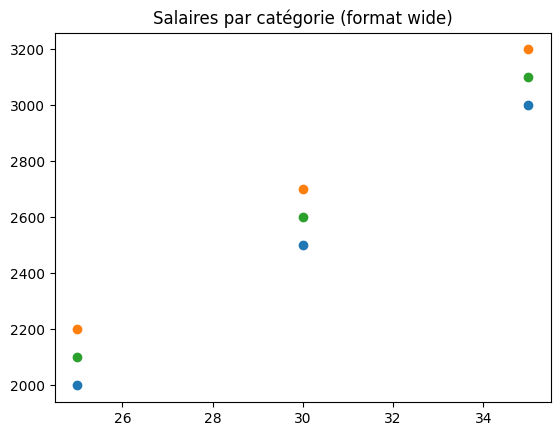

In [ ]:
# Exemple en format WIDE (pas idéal pour Seaborn)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset au format wide
df_wide = pd.DataFrame({
    "age": [25, 30, 35],
    "salaire_A": [2000, 2500, 3000],
    "salaire_B": [2200, 2700, 3200],
    "salaire_C": [2100, 2600, 3100],
})

# Tentative directe avec Seaborn (limitée)
plt.scatter(df_wide["age"], df_wide["salaire_A"], label="A")
plt.scatter(df_wide["age"], df_wide["salaire_B"], label="B")
plt.scatter(df_wide["age"], df_wide["salaire_C"], label="C")
plt.title("Salaires par catégorie (format wide)")
plt.show()

# ⚠️ Problèmes
# Seaborn ne connaît pas les catégories
# Les noms de colonnes deviennent les labels
# Tu perds le lien explicite catégorie ↔ variable
# ⚠️ Fonctionne
# ❌ Répétitif
# ❌ Non scalable
# ❌ Pas Seaborn-friendly

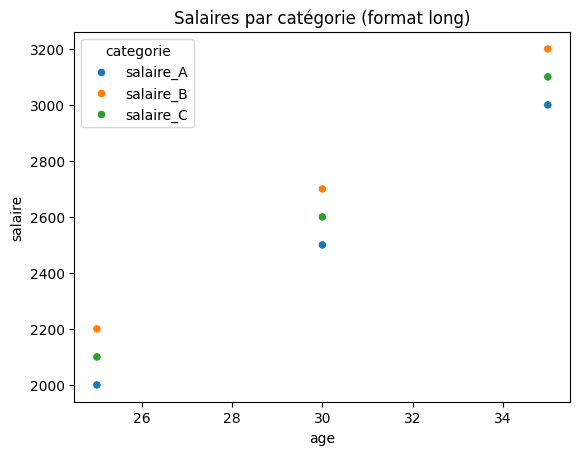

In [19]:
# Le MÊME graphique en format LONG (bonne pratique)

# Conversion wide → long
df_long = df_wide.melt(
    id_vars="age",
    var_name="categorie",
    value_name="salaire"
)

# Visualisation avec Seaborn (propre et expressive)
fig, ax = plt.subplots()

sns.scatterplot(
    x="age",
    y="salaire",
    hue="categorie",
    data=df_long
)

ax.set_title("Salaires par catégorie (format long)")
plt.show()